# Beta Estimation Research

## Research Design

- **研究对象**：CRSP 月度个股收益与 Fama-French 月度市场因子。
- **核心模型**：CAPM 回归 `ret_excess ~ mkt_excess`。
- **估计方法**：先对单只股票做静态 OLS 示例，再用 60 个月滚动窗口估计动态 beta。
- **展示维度**：代表性股票 beta 路径、行业 beta 分布、截面 beta 分位数变化。
- **本地数据目录**：`D:\stata\For Students\csv`。



In [4]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.formula.api as smf

from statsmodels.regression.rolling import RollingOLS
from plotnine import *
# from mizani.breaks import breaks_date_width
from mizani.formatters import percent_format, date_format


from joblib import Parallel, delayed, cpu_count
from itertools import product

import warnings
warnings.filterwarnings("ignore")  # 忽略所有 warning


## 1. Data Loading


In [5]:
crsp_monthly = pd.read_csv(r"D:\stata\For Students\csv\crsp_monthly.csv").get(['permno', 'date', 'industry', 'ret_excess'])
crsp_monthly = crsp_monthly.dropna()
crsp_monthly['date'] = pd.to_datetime(crsp_monthly['date'])

factors_ff3_monthly = pd.read_csv(r"D:\stata\For Students\csv\factors_ff3_monthly.csv").get([ 'date', 'mkt_excess'])
factors_ff3_monthly['date']=pd.to_datetime(factors_ff3_monthly['date'])

crsp_monthly = (crsp_monthly
  .merge(factors_ff3_monthly, how="left", on="date")
)

crsp_monthly.head()

,permno,date,industry,ret_excess,mkt_excess
0,10028,1993-03-01,Wholesale,-0.102500,0.0230
1,10028,1993-04-01,Wholesale,0.386489,-0.0305
2,10028,1993-05-01,Wholesale,0.197800,0.0289
3,10028,1993-06-01,Wholesale,-0.135833,0.0031
4,10028,1993-07-01,Wholesale,0.189908,-0.0034


## 2. Baseline CAPM Regression


In [6]:
model_fit = smf.ols(
    formula="ret_excess ~ mkt_excess", data=crsp_monthly.query("permno == 14593")
).fit()
coefficients = model_fit.summary2().tables[1]
coefficients

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.010185,0.005084,2.003344,4.567744e-02,0.000196,0.020174
mkt_excess,1.388894,0.111407,12.466849,2.880541e-31,1.170013,1.607776


## 3. Rolling Monthly Beta Estimation

为了刻画 beta 的时间变化，使用 60 个月滚动窗口，并要求至少 48 个月有效观测值。这样可以减少短样本带来的不稳定估计。


In [7]:
window_size = 60
min_obs = 48

valid_permnos = (crsp_monthly
  .dropna()
  .groupby("permno")["permno"]
  .count()
  .reset_index(name="counts")
  .query(f"counts > {window_size}+1")
)
valid_permnos.head()

,permno,counts
1,10001,378
2,10002,324
3,10003,118
4,10005,65
5,10006,292


In [8]:
permno_information = (crsp_monthly
  .merge(valid_permnos, how="inner", on="permno")
  .groupby(["permno"])
  .aggregate(first_date=("date", "min"),
             last_date=("date", "max"))
  .reset_index()
)
permno_information.head()

,permno,first_date,last_date
0,10001,1986-02-01,2017-07-01
1,10002,1986-02-01,2013-01-01
2,10003,1986-02-01,1995-11-01
3,10005,1986-02-01,1991-06-01
4,10006,1960-02-01,1984-05-01


In [9]:
unique_permno = crsp_monthly["permno"].unique()
unique_month = factors_ff3_monthly["date"].unique()

all_combinations = pd.DataFrame(
    product(unique_permno, unique_month), 
    columns=["permno", "date"]
)
all_combinations.head()

,permno,date
0,10028,1960-01-01
1,10028,1960-02-01
2,10028,1960-03-01
3,10028,1960-04-01
4,10028,1960-05-01


In [10]:
returns_monthly = (all_combinations
  .merge(crsp_monthly.get(["permno", "date", "ret_excess"]), how="left", on=["permno", "date"])
  .merge(permno_information, how="left", on="permno")
  .query("(date >= first_date) & (date <= last_date)")
  .drop(columns=["first_date", "last_date"])
  .merge(crsp_monthly.get(["permno", "date", "industry"]), how="left", on=["permno", "date"])
  .merge(factors_ff3_monthly, how="left", on="date")
)
returns_monthly.head()

,permno,date,ret_excess,industry,mkt_excess
0,10028,1986-03-01,0.216222,Mining,0.0488
1,10028,1986-04-01,0.176618,Mining,-0.0131
2,10028,1986-05-01,0.148946,Mining,0.0462
3,10028,1986-06-01,-0.138533,Mining,0.0103
4,10028,1986-07-01,-0.582123,Mining,-0.0645


In [11]:
def roll_capm_estimation(data, window_size, min_obs):
    """Calculate rolling CAPM estimation."""
    
    data = data.sort_values("date")

    result = (RollingOLS.from_formula(
        formula="ret_excess ~ mkt_excess",
        data=data,
        window=window_size,
        min_nobs=min_obs,
        missing="drop")
        .fit()
        .params.get("mkt_excess")
    )
    
    result.index = data.index
    
    return result

## 4. Example Stocks

选取 Apple、Microsoft、Tesla 和 Berkshire Hathaway 作为代表性股票，观察不同商业模式和风险暴露下的 beta 路径。


In [12]:
examples = pd.DataFrame({
    "permno": [14593, 10107, 93436, 17778],
    "company": ["Apple", "Microsoft", "Tesla", "Berkshire Hathaway"]
})

In [13]:
beta_example = (returns_monthly
  .merge(examples, how = "inner", on = "permno")
  .groupby(["permno"])
  .apply(lambda x: x.assign(
    beta = roll_capm_estimation(x, window_size, min_obs))
  )
  .reset_index(drop = True)
  .dropna()
)
beta_example.head()

,date,ret_excess,industry,mkt_excess,company,beta
59,1991-03-01,0.018492,Services,0.0265,Microsoft,1.411268
60,1991-04-01,-0.072438,Services,-0.0028,Microsoft,1.431428
61,1991-05-01,0.103886,Services,0.0365,Microsoft,1.441396
62,1991-06-01,-0.073107,Services,-0.0494,Microsoft,1.460013
63,1991-07-01,0.073999,Services,0.0424,Microsoft,1.443456


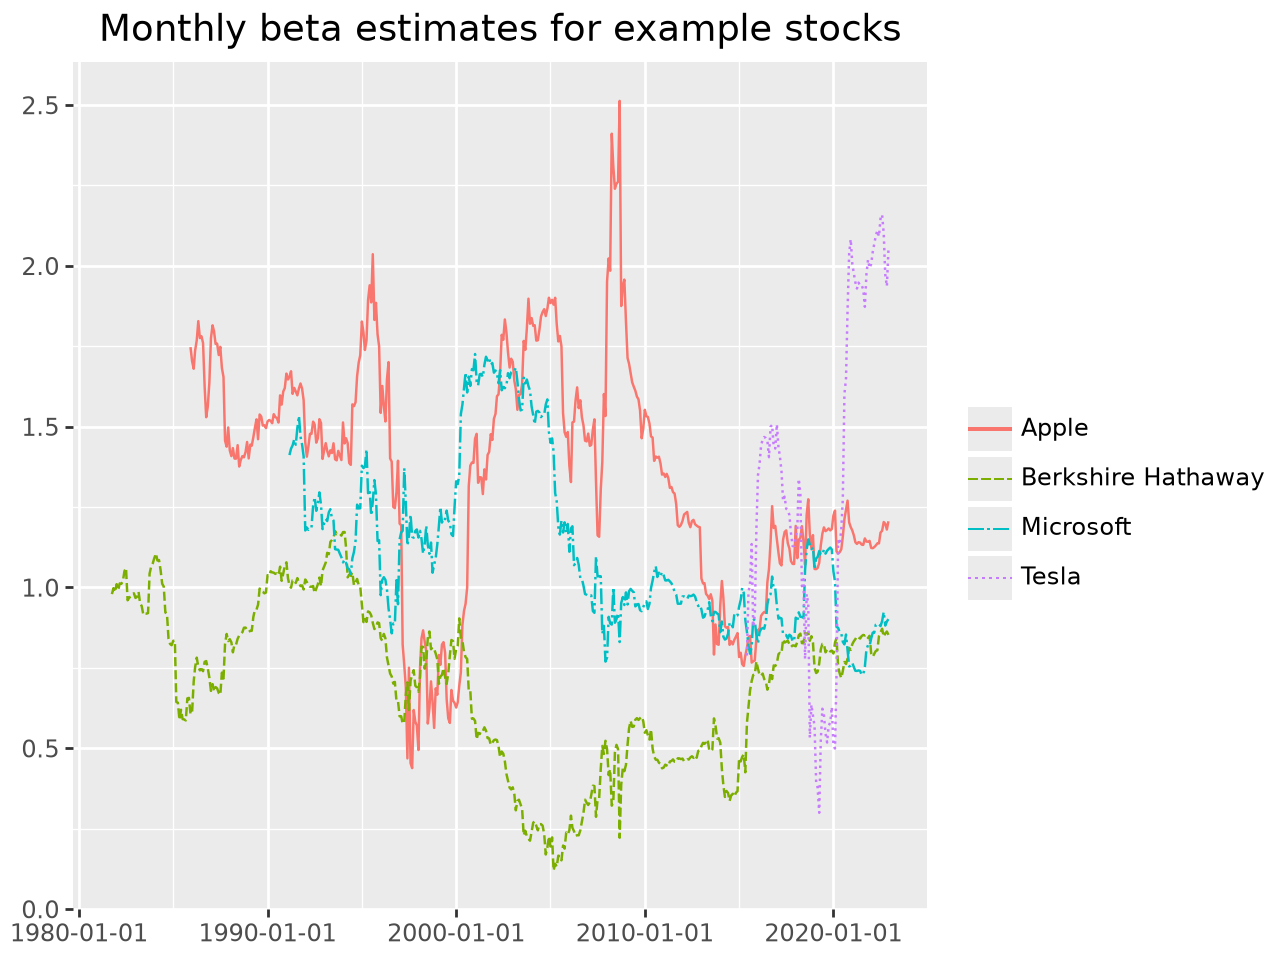

In [14]:

plot_beta = (
  ggplot(
    beta_example, 
    aes(x="date", y="beta", color="company", linetype="company")
  )
  + geom_line()
  + labs(
      x="", y="", color="", linetype="",
      title="Monthly beta estimates for example stocks"
    )
  #+ scale_x_datetime(breaks=breaks_date_width(width="5 year"), labels=date_format("%Y"))
)

plot_beta.show()

## 5. Full-Sample Monthly Beta

在全样本股票上进行滚动窗口估计，并保留每只股票每个月的 `beta_monthly`。这里保留原始代码中的并行计算实现，用于处理较大的 CRSP 月度样本。


In [15]:
import time
# 记录代码开始运行时间
start_time = time.time()

In [16]:
def roll_capm_estimation_for_joblib(permno, group):
    """Calculate rolling CAPM estimation using joblib."""
    
    group = group.sort_values(by = "date")

    beta_values = (RollingOLS.from_formula(
        formula = "ret_excess ~ mkt_excess",
        data = group,
        window = window_size,
        min_nobs = min_obs,
        missing = "drop"
      )
      .fit()
      .params.get("mkt_excess")
    )
    
    result = pd.DataFrame(beta_values)
    result.columns = ["beta"]
    result["date"] = group["date"].values
    result["permno"] = permno
    
    return result

In [17]:
# 记录代码开始运行时间
start_time = time.time()

permno_groups = (
    returns_monthly
    .merge(valid_permnos, how="inner", on="permno")
    .groupby("permno", group_keys=False)
)

n_cores = cpu_count() - 1

beta_monthly = (
    pd.concat(
        Parallel(n_jobs=n_cores)(
            delayed(roll_capm_estimation_for_joblib)(name, group)
            for name, group in permno_groups
        )
    )
    .dropna()
    .rename(columns={"beta": "beta_monthly"})
)

# 记录代码结束运行时间 
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60
print(f"代码运行时间: {elapsed_minutes:.2f} 分钟")

beta_monthly.head()

代码运行时间: 0.68 分钟


,beta_monthly,date,permno
1467,0.097436,1991-01-01,10001
1468,0.094800,1991-02-01,10001
1469,0.089890,1991-03-01,10001
1470,0.088488,1991-04-01,10001
1471,0.091946,1991-05-01,10001


## 6. Industry-Level Beta Distribution

将估计出的月度 beta 与行业信息合并，比较不同行业的 beta 分布。该图可以用来识别市场敏感度较高或较低的行业。


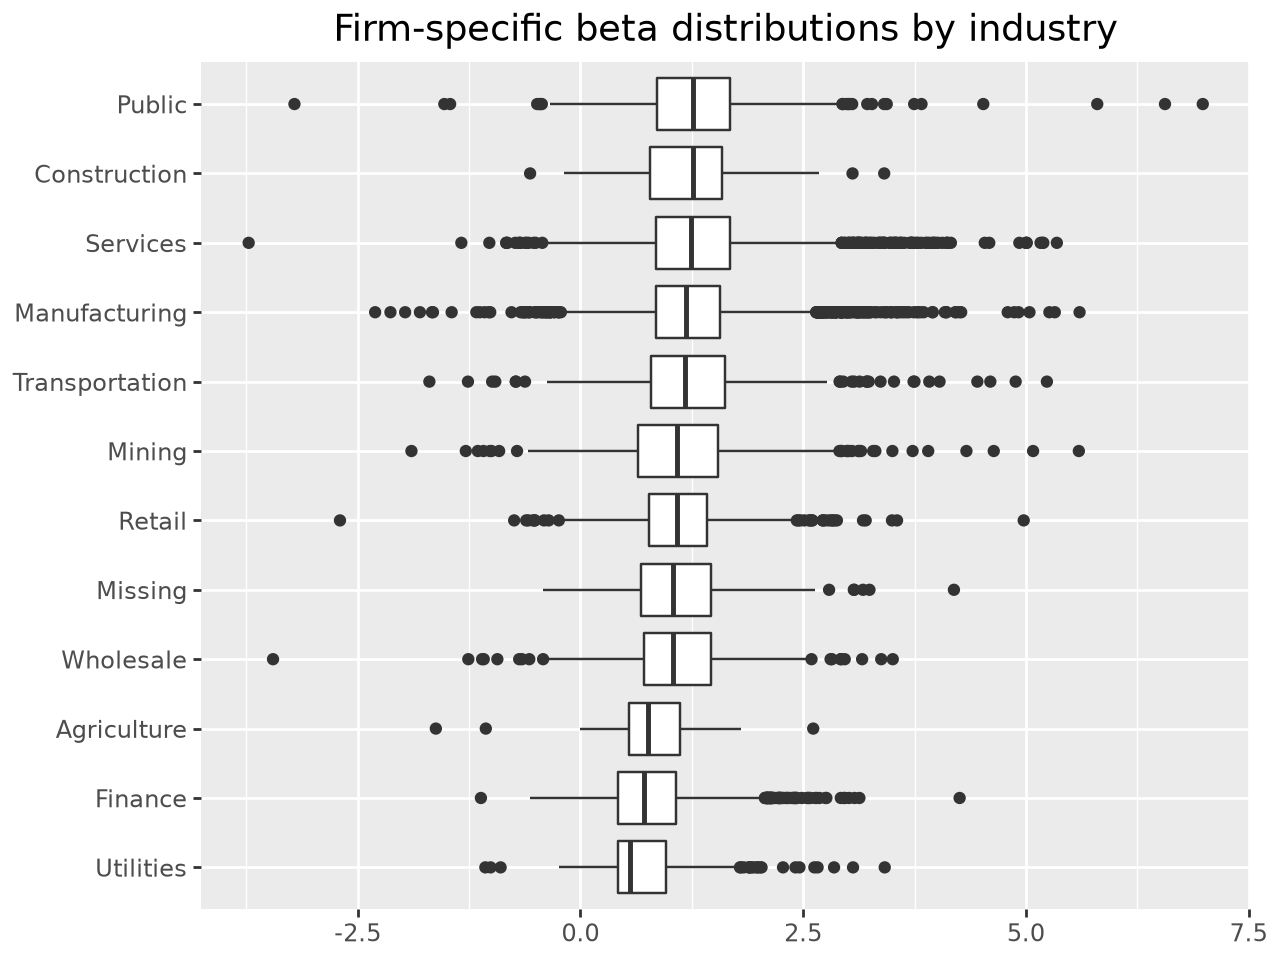

In [18]:
beta_industries = (beta_monthly
  .merge(crsp_monthly, how="inner", on=["permno", "date"])
  .dropna(subset="beta_monthly")
  .groupby(["industry","permno"])["beta_monthly"]
  .aggregate("mean")
  .reset_index()
)

industry_order = (beta_industries
  .groupby("industry")["beta_monthly"]
  .aggregate("median")
  .sort_values()
  .index.tolist()
)
industry_order

plot_beta_industries = (
  ggplot(
    beta_industries, 
    aes(x="industry", y="beta_monthly")
  )
  + geom_boxplot()
  + coord_flip()
  + labs(
      x="", y="", 
      title="Firm-specific beta distributions by industry"
    )
  + scale_x_discrete(limits=industry_order)
)
plot_beta_industries.show()

## 7. Cross-Sectional Beta Quantiles

按月份计算 beta 的 10% 到 90% 分位数，观察市场风险暴露在横截面上的整体变化。分位数曲线如果同时上移或下移，说明市场阶段性风险暴露具有共同变化。


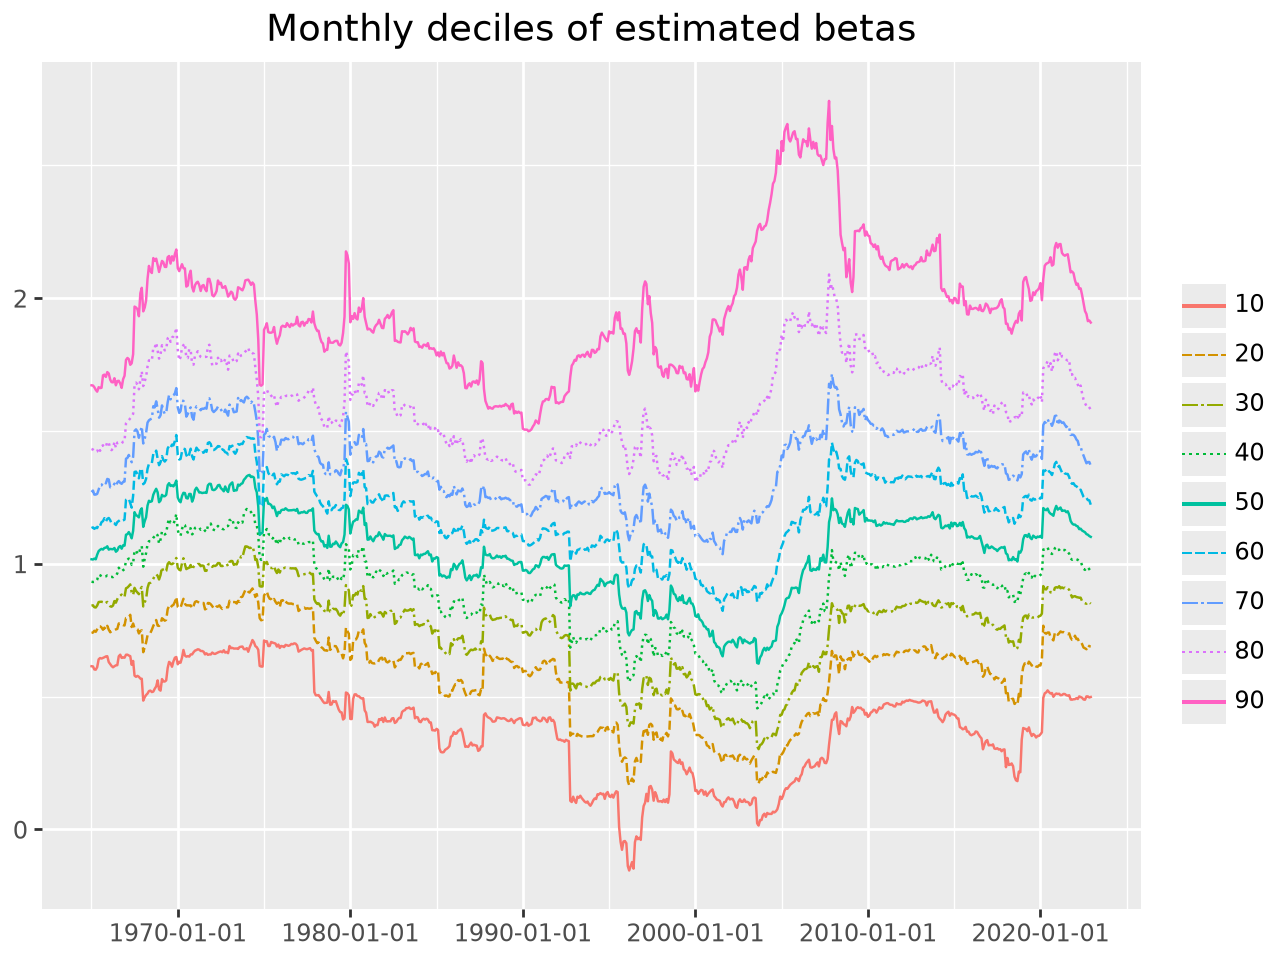

In [19]:
beta_quantiles = (beta_monthly
  .groupby("date")["beta_monthly"]
  .quantile(q=np.arange(0.1, 1.0, 0.1))
  .reset_index()
  .rename(columns={"level_1": "quantile"})
  .assign(quantile=lambda x: (x["quantile"]*100).astype(int))
  .dropna()
)

linetypes = ["-", "--", "-.", ":"]
n_quantiles = beta_quantiles["quantile"].nunique()

plot_beta_quantiles = (
  ggplot(
    beta_quantiles, 
    aes(x="date", y="beta_monthly", color="factor(quantile)", linetype="factor(quantile)")
  )
  + geom_line()
  + labs(
      x="", y="", color="", linetype="",
      title="Monthly deciles of estimated betas"
    )
  #+ scale_x_datetime(breaks=date_breaks(width="5 year"), labels=date_format("%Y"))
  + scale_linetype_manual(
      values=[linetypes[l % len(linetypes)] for l in range(n_quantiles)]
    ) 
)
plot_beta_quantiles.show()

## Research Summary

本研究从 CAPM 出发，完成了个股 beta 的月度滚动估计，并从代表性股票、行业分布和横截面分位数三个角度展示 beta 的变化特征。